<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

sns.set(style="whitegrid")


1. Simularemos señales en 3 clases:

  - Sano: señal sinusoidal limpia + algo de ruido blanco.

  -  Fallo incipiente: se añaden pequeñas irregularidades (picos, modulación).

  -  Fallo severo: se incluyen patrones impulsivos, modulación irregular, ruido fuerte.

In [6]:
def generate_signal(state, fs=10000, duration=1.0):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    base_signal = np.sin(2 * np.pi * 50 * t)  # 50 Hz vibración base

    if state == 'sano':
        noise = np.random.normal(0, 0.05, len(t))
        return base_signal + noise

    elif state == 'incipiente':
        mod = 0.3 * np.sin(2 * np.pi * 10 * t)  # modulación baja frecuencia
        spikes = np.random.normal(0, 0.1, len(t))
        return base_signal * (1 + mod) + spikes

    elif state == 'fallo':
        impulsos = np.zeros_like(t)
        impulsos[np.random.randint(0, len(t), 50)] = np.random.uniform(-2, 2, 50)
        ruido = np.random.normal(0, 0.2, len(t))
        return base_signal + impulsos + ruido


2. Generar dataset etiquetado

In [7]:
import pandas as pd

def generate_dataset(n_samples_per_class=100):
    X = []
    y = []
    estados = ['sano', 'incipiente', 'fallo']

    for estado in estados:
        for _ in range(n_samples_per_class):
            signal = generate_signal(estado)
            features = extract_features(signal)  # Esta función la defines tú (ver más abajo)
            X.append(features)
            y.append(estado)

    return pd.DataFrame(X), np.array(y)


3. Extract_Features

In [8]:
def extract_features(signal):
    return {
        'rms': np.sqrt(np.mean(signal**2)),
        'kurtosis': kurtosis(signal),
        'skewness': skew(signal),
        'peak': np.max(np.abs(signal)),
        'std': np.std(signal)
    }


4. Generate Dataset

In [9]:
X_df, y = generate_dataset()

5. Visualización de señales

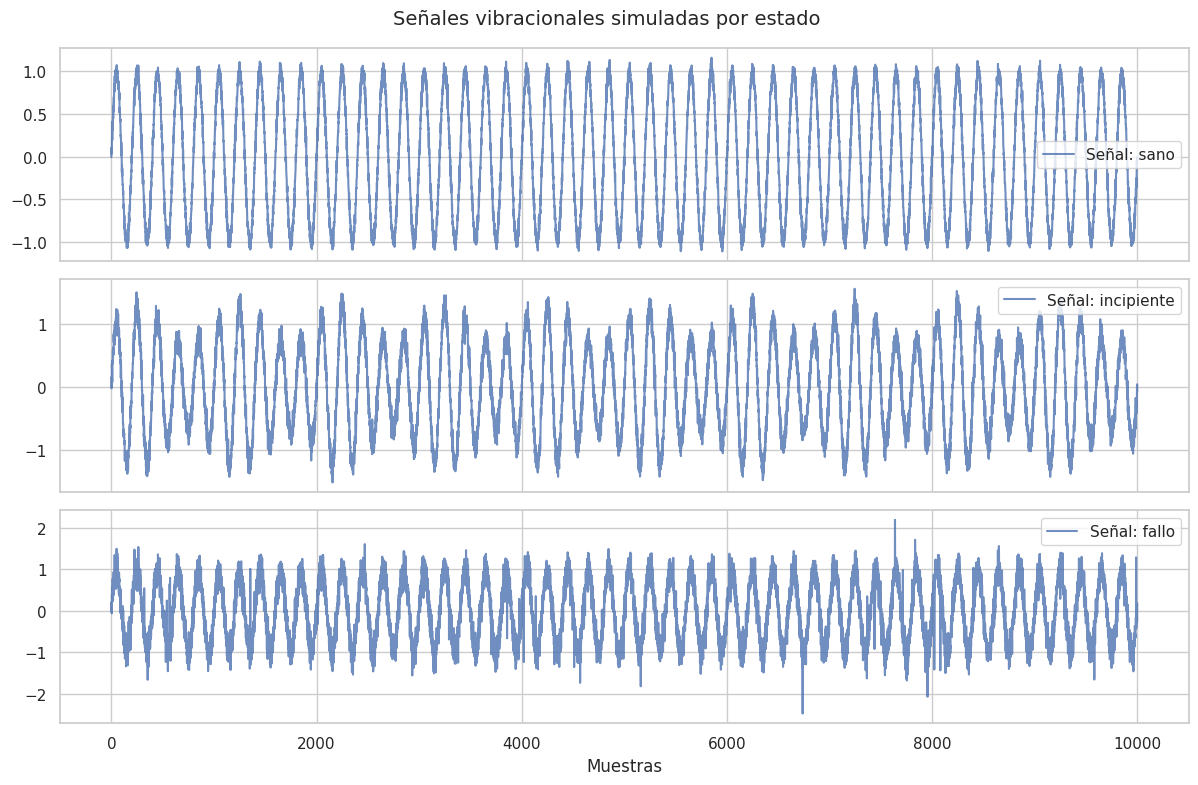

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
estados = ['sano', 'incipiente', 'fallo']
for i, estado in enumerate(estados):
    axs[i].plot(generate_signal(estado), label=f'Señal: {estado}', alpha=0.8)
    axs[i].legend()
    axs[i].grid(True)
plt.suptitle("Señales vibracionales simuladas por estado", fontsize=14)
plt.xlabel("Muestras")
plt.tight_layout()
plt.show()


6. Visualización de características por clase

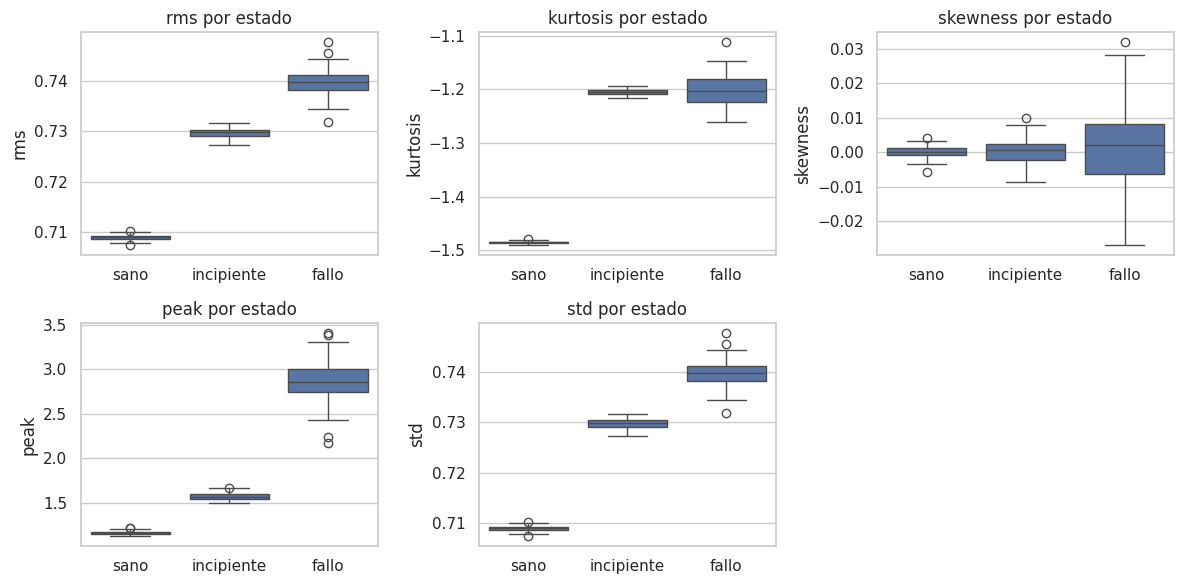

In [11]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(X_df.columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=y, y=X_df[col])
    plt.title(f"{col} por estado")
plt.tight_layout()
plt.show()


7. Entrenar un clasificador

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, stratify=y)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       fallo       1.00      1.00      1.00        20
  incipiente       1.00      1.00      1.00        20
        sano       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



8. Matriz de confusion

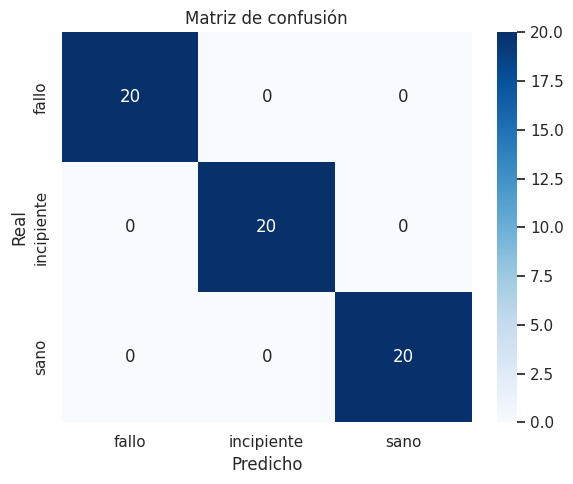

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


9. Prediccion

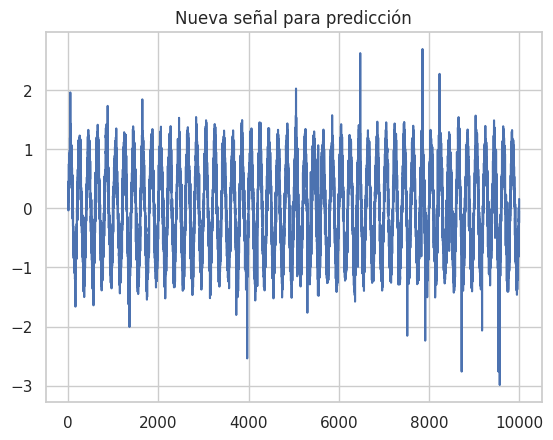

Predicción del modelo: fallo


In [15]:
# Crear una nueva señal (simula un estado cualquiera, por ejemplo fallo)
nueva_senal = generate_signal('fallo')  # Puedes cambiar a 'sano', 'fallo', etc.

# Ver la señal
plt.plot(nueva_senal)
plt.title("Nueva señal para predicción")
plt.grid(True)
plt.show()

# Extraer características y predecir
caracteristicas_nuevas = extract_features(nueva_senal)
caracteristicas_df = pd.DataFrame([caracteristicas_nuevas])
prediccion = clf.predict(caracteristicas_df)
print("Predicción del modelo:", prediccion[0])
